In [1]:
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from cmocean import cm as cmo
from cartopy import crs as ccrs
from cartopy import feature as cfeature
import xarray as xr
import numpy as np

# Open data

In [2]:
# Path to Crocolake
parquet_dir = '/home/jovyan/shared/go-bgc-2026/data/CrocoLake/BGC_CROCOLAKE/'

# path to heatwave csv
csv_path = '../../MHW_list.csv'

dfhw = pd.read_csv(csv_path)
dfhw.set_index('name',inplace=True)
date_cols = ['date_start','date_end']
dfhw[date_cols] = dfhw[date_cols].apply(pd.to_datetime)

# Choose a HW
hw = 'SWPac2023'# 'NA 2023'  #'SWPac2023'

# Boundaries
lat0 = dfhw.loc[hw,'lat0'] 
lat1 = dfhw.loc[hw,'lat1'] 
lon0 = dfhw.loc[hw,'lon0'] 
lon1 = dfhw.loc[hw,'lon1'] 

date0 = dfhw.loc[hw,'date_start']
date1 = dfhw.loc[hw,'date_end']

if hw == 'NA 2023':
    date0 = pd.to_datetime('2023-03-01')
    date1 = pd.to_datetime('2023-12-01')

if hw == 'SWPac2023':
    date0 = pd.to_datetime('2022-06-01')
    date1 = pd.to_datetime('2024-06-01')

print([lat0.item(), lat1.item(), lon0.item(), lon1.item(), date0, date1])

[-60, -40, 150, -140, Timestamp('2022-06-01 00:00:00'), Timestamp('2024-06-01 00:00:00')]


In [3]:
# Parameters
columns = [
    'PRES',
    'TEMP',
    'PSAL',
    'DOXY',
    'ABS_SAL_COMPUTED',
    'CONSERVATIVE_TEMP_COMPUTED',
    'LATITUDE',
    'LONGITUDE',
    'JULD',
    'CYCLE_NUMBER',
    'PLATFORM_NUMBER',
    'DB_NAME',
]

# Check if lons cross 180
if lon0 > lon1:
    lon0_1, lon1_1 = lon0, 180
    lon0_2, lon1_2 = -180, lon1
    filters_1 = [
        ("LATITUDE",">=",lat0), ("LATITUDE","<=",lat1),
        ("LONGITUDE",">=",lon0_1), ("LONGITUDE","<=",lon1_1),
        ("JULD",">=",date0), ("JULD","<=",date1),
        ("DB_NAME","=","ARGO") 
    ]
    filters_2 = [
        ("LATITUDE",">=",lat0), ("LATITUDE","<=",lat1),
        ("LONGITUDE",">=",lon0_2), ("LONGITUDE","<=",lon1_2),
        ("JULD",">=",date0), ("JULD","<=",date1),
        ("DB_NAME","=","ARGO") 
    ]
    df_1 = pd.read_parquet(parquet_dir,columns=columns,filters=filters_1)
    df_2 = pd.read_parquet(parquet_dir,columns=columns,filters=filters_2)
    df = pd.concat([df_1, df_2], axis=0)
else:
    # without DB_NAME you also would get any Spray glider or shipboard GLODAP data too
    filters = [
        ("LATITUDE",">=",lat0), ("LATITUDE","<=",lat1),
        ("LONGITUDE",">=",lon0), ("LONGITUDE","<=",lon1),
        ("JULD",">=",date0), ("JULD","<=",date1),
        ("DB_NAME","=","ARGO") 
    ]
    df = pd.read_parquet(parquet_dir,columns=columns,filters=filters)

In [4]:
df['PLATFORM_PROFILE'] = [str(pn)+'_'+str(cn) for pn, cn in zip(df['PLATFORM_NUMBER'].values, df['CYCLE_NUMBER'].values)]

994 profiles from 39 platforms.


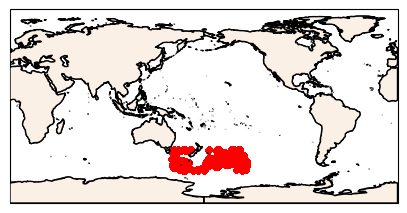

In [5]:
print(f'{len(df.PLATFORM_PROFILE.unique())} profiles from {len(df.PLATFORM_NUMBER.unique())} platforms.')

fig, ax = plt.subplots(1, 1, figsize=(5, 5), subplot_kw={'projection': ccrs.PlateCarree(180)})
ax.coastlines(resolution = "50m", zorder=5, linewidth = 1)
ax.add_feature(cfeature.LAND, zorder=5, linewidth = 1, edgecolor='k', facecolor='linen')
ax.set_global()

ax.scatter(df.LONGITUDE, df.LATITUDE, c='r', s=8, transform=ccrs.PlateCarree())
plt.show()

# Get Climo

In [6]:
bucket = 's3://uw-escience-scratch-prod/team_mhw'
o2_climo_fname = 'GOBAI-O2-v2.3_oxygen_2004-2024_monthly_climatology.nc'

o2_climo = xr.open_dataset(f'{bucket}/{o2_climo_fname}', engine='h5netcdf')

In [7]:
temp_climo_fname = 'RG09_potential_temperature_2004-2024_monthly_climatology_interpolated_pres_0-1000dbar.nc'
temp_climo = xr.open_dataset(f'{bucket}/{temp_climo_fname}', engine='h5netcdf')

# Interpolate float oxygen

In [8]:
df_oxy = df[~np.isnan(df['DOXY'])].copy()
df_oxy['month'] = df_oxy['JULD'].dt.month
ex = df_oxy.iloc[0:3].reset_index()
ex['gobai_oxy'] = np.empty(len(ex))

# for i in range(3):
#     ex.loc[i, 'gobai_oxy'] = o2_climo['oxy'].sel(
#         lat=ex.iloc[i].LATITUDE,
#         lon=ex.iloc[i].LONGITUDE,
#         month=ex.iloc[i].month,
#         method='nearest').values[0]
# df['Group_UUID'] = df.groupby('Group')['Group'].transform(lambda x: get_oxy(x))

In [9]:
ds_ex = xr.open_dataset('~/swp_test_5profiles.nc')

In [10]:
ds_ex

<xarray.Dataset> Size: 88kB
Dimensions:          (profile: 5, pres: 1001)
Coordinates:
  * pres             (pres) int64 8kB 0 1 2 3 4 5 6 ... 995 996 997 998 999 1000
  * profile          (profile) int64 40B 0 1 2 3 4
    PLATFORM_NUMBER  (profile) int64 40B ...
    CYCLE_NUMBER     (profile) int64 40B ...
    JULD             (profile) datetime64[ns] 40B ...
    LATITUDE         (profile) float64 40B ...
    LONGITUDE        (profile) float64 40B ...
Data variables:
    TEMP_ADJUSTED    (profile, pres) float64 40kB ...
    PSAL_ADJUSTED    (profile, pres) float64 40kB ...
Attributes:
    region:       swp
    depth_units:  decibar
    max_depth:    1000

In [11]:
matched_climo = temp_climo['temp'].sel(lat=ds_ex['LATITUDE'],
                       lon=ds_ex['LONGITUDE'],
                       month=ds_ex['JULD'].dt.month,
                       method='nearest')

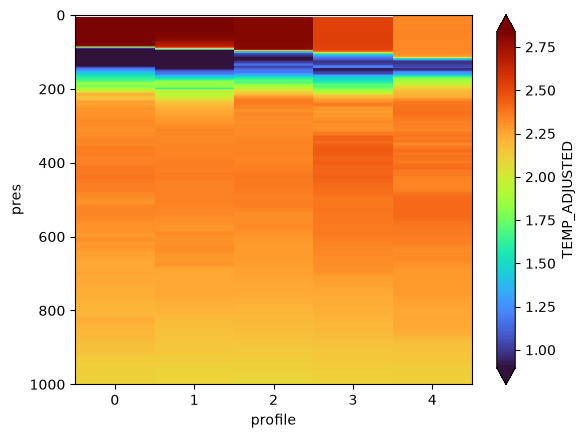

In [12]:
ds_ex['TEMP_ADJUSTED'].T.plot(cmap='turbo', robust=True)
plt.gca().invert_yaxis()

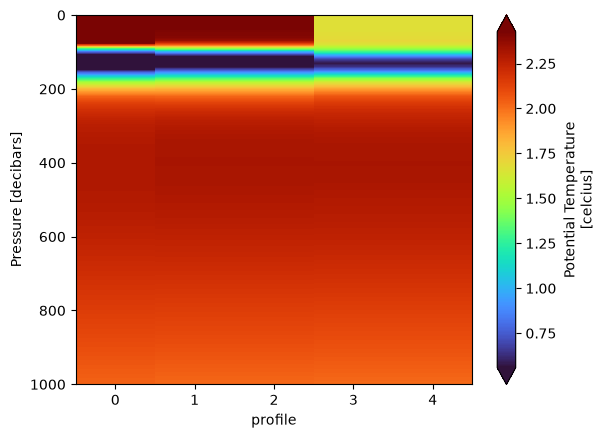

In [13]:
matched_climo.T.plot(cmap='turbo', robust=True)
plt.gca().invert_yaxis()

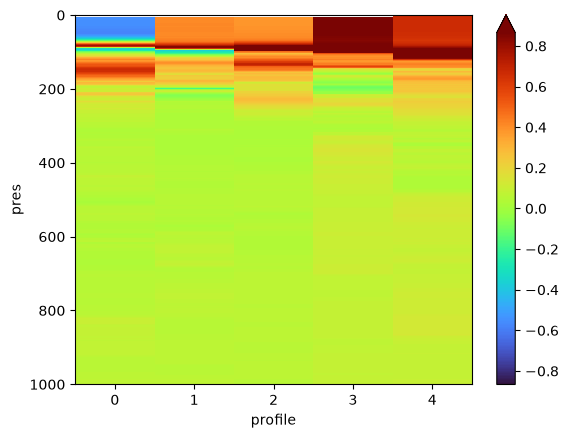

In [14]:
(ds_ex['TEMP_ADJUSTED']-matched_climo).T.plot(cmap='turbo', robust=True)
plt.gca().invert_yaxis()

In [47]:
def convert_lons(da, dim='lon'):
    da.coords[dim] = (((360 + (da[dim] % 360)) % 360))
    da_new_lon = da.sortby(da[dim])
    return da_new_lon

In [30]:
mhw_swp_mask = xr.open_zarr(f's3://uw-escience-scratch-prod/oisst/mhw_mask_swp_final.zarr').compute()

In [48]:
float_profiles_180 = xr.open_zarr('s3://uw-escience-scratch-prod/team_mhw/regridded_floats/swp_regridded_profiles_full.zarr').compute()
float_profiles = convert_lons(float_profiles_180, dim='LONGITUDE')

In [49]:
# NEED TO CONVERT LONGITUDE SO WRAPPING DOESN'T BREAK IT!

float_profiles_mhw_mask = mhw_swp_mask['mhw_mask'].sel(lat=float_profiles['LATITUDE'],
                                                       lon=float_profiles['LONGITUDE'],
                                                       time=float_profiles['JULD'].dt.date,
                                                       method='nearest')

In [50]:
mhw_float = float_profiles_mhw_mask.where(float_profiles_mhw_mask==1, np.nan, drop=True)
non_mhw_float = float_profiles_mhw_mask.where(float_profiles_mhw_mask==0, np.nan, drop=True)

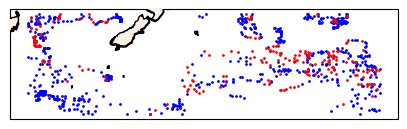

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5), subplot_kw={'projection': ccrs.PlateCarree(180)})
ax.coastlines(resolution = "50m", zorder=5, linewidth = 1)
ax.add_feature(cfeature.LAND, zorder=5, linewidth = 1, edgecolor='k', facecolor='linen')
# ax.set_global()

ax.scatter(non_mhw_float.lon, non_mhw_float.lat, c='blue', s=1, transform=ccrs.PlateCarree())
ax.scatter(mhw_float.lon, mhw_float.lat, c='r', s=1, transform=ccrs.PlateCarree())
# ax.scatter(float_profiles.LONGITUDE, float_profiles.LATITUDE, c='r', s=1, transform=ccrs.PlateCarree())

plt.show()